In [2]:
%cd ../

/home/student/pubtrends


In [3]:
!pwd

/home/student/pubtrends


In [4]:
import logging


logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

In [5]:
import logging

import numpy as np
import pandas as pd

from pysrc.papers.db.loader import Loader
from pysrc.papers.db.postgres_connector import PostgresConnector
from pysrc.papers.db.postgres_utils import preprocess_search_query_for_postgres, \
    process_bibliographic_coupling_postgres, process_cocitations_postgres, no_stemming_filter
from pysrc.papers.utils import crc32, SORT_MOST_CITED, SORT_MOST_RECENT, preprocess_doi, \
    preprocess_search_title

logger = logging.getLogger(__name__)

import logging
import html
import pandas as pd
import numpy as np
import networkx as nx
import random
import hashlib
from tqdm.auto import tqdm

from pysrc.prediction.ss_arxiv_loader import SSArxivLoader
from pysrc.prediction.ss_pubmed_loader import SSPubmedLoader
from pysrc.papers.db.pm_postgres_loader import PubmedPostgresLoader
from pysrc.prediction.predict_analyzer import PredictAnalyzer
from pysrc.papers.config import PubtrendsConfig
from pysrc.papers.db.ss_postgres_loader import SemanticScholarPostgresLoader
from pysrc.papers.db.postgres_connector import PostgresConnector
from collections import defaultdict



class CustomLoader(SemanticScholarPostgresLoader):
    def __init__(self, config):
        super(CustomLoader, self).__init__(config)

    def load_func(self, limit=100):
        self.check_connection()
        if limit is None:
            query = '''SELECT ssid, aux::json->'authors' FROM sspublications'''
        else:
            query = f'''
                    SELECT ssid, aux::json->'authors' FROM sspublications LIMIT {limit}
            '''
        result = defaultdict(list)
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            for item in cursor:
                ind, names = item
                for i, el in enumerate(names):
                    result[el['name']].append((ind, int(i == 0)))
            return result
    
    def custom_query(self, query):
        self.check_connection()
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            return cursor.fetchall()
    
    def create_subsample(self, threshold=0.01, seed=42):
        self.check_connection()
        random.seed(seed)
        ssids, crc32ids = [], []
        query = '''select ssid, crc32id from sspublications'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            for item in cursor:
                if random.random() < threshold:
                    ss, crc = item
                    ssids.append(ss)
                    crc32ids.append(crc)
            return ssids, crc32ids


class CustomWriter(PostgresConnector):

    def __init__(self, config):
        super(CustomWriter, self).__init__(config, readonly=False)
        
    def insert_table_publications(self, ids):
        self.check_connection()
        query = f'''CREATE TABLE IF NOT EXISTS sspublications_sample AS 
            (SELECT * FROM sspublications WHERE ssid IN ({', '.join(map(lambda x: "'" + str(x) + "'", ids))}))'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            self.postgres_connection.commit()
        
    def insert_table_citations(self, ids):
        self.check_connection()
        query = f'''CREATE TABLE IF NOT EXISTS sscit_sample AS 
            (SELECT * FROM sscitations WHERE crc32id_in IN ({', '.join(map(lambda x: "'" + str(x) + "'", ids))}));
            create index if not exists sscit_crc32id_in on sscit_sample (crc32id_in);'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            self.postgres_connection.commit()
    
    def execute_custom_query(self, query):
        try:
            self.check_connection()
            with self.postgres_connection.cursor() as cursor:
                cursor.execute(query)
                self.postgres_connection.commit()
        except Exception as e:
            print(e)



2021-09-08 14:50:13,494 INFO: NumExpr defaulting to 8 threads.


In [4]:
config = PubtrendsConfig(test=False)
loader = CustomLoader(config)
writer = CustomWriter(config)

### English titles

In [5]:
%%time
q = '''select ssid, title from sspublications_sample where lang='en';'''
titles = loader.custom_query(q)

CPU times: user 585 ms, sys: 201 ms, total: 786 ms
Wall time: 17 s


### English abstracts

In [6]:
%%time
q = '''select ssid, abstract from sspublications_sample where lang='en' and abstract is not NULL;'''
abstracts = loader.custom_query(q)

CPU times: user 1.14 s, sys: 1.02 s, total: 2.16 s
Wall time: 10.1 s


In [7]:
len(titles), len(abstracts)

(1134376, 727314)

In [8]:
def create_subsample(data, size=0.1, seed=42):
    result = []
    random.seed(seed)
    for item in data:
        if random.random() < 0.05:
            result.append(item)
    return result

In [9]:
sub_titles, sub_abs = create_subsample(titles), create_subsample(abstracts)

In [10]:
len(sub_titles), len(sub_abs)

(56649, 36104)

### LDA experiments

1. Create represantive subsample of all papers from database to speed up calculations
2. Select effective number of topics.

In [12]:
from gensim.models import CoherenceModel

In [13]:
corpus_titles = [f'{item}' for ssid, item in sub_titles]
corpus_abs = [f'{item}' for ssid, item in sub_abs]

In [20]:
!python3 -m pip install pyldavis

     |████████████████████████████████| 1.7 MB 1.6 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 829 kB 26.6 MB/s eta 0:00:01
     |████████████████████████████████| 471 kB 29.8 MB/s eta 0:00:01
     |████████████████████████████████| 11.3 MB 76.3 MB/s eta 0:00:01
  Created wheel for pyldavis: filename=pyLDAvis-3.3.1-py2.py3-none-any.whl size=136897 sha256=0a1ccb1b9593810bfc02fd785b196a73982b53da60d19162922bfeed3e506e3e
  Stored in directory: /home/student/.cache/pip/wheels/c9/21/f6/17bcf2667e8a68532ba2fbf6d5c72fdf4c7f7d9abfa4852d2f
  Created wheel for sklearn: filename=sklearn-0.0-py2.py3-none-any.whl size=1316 sha256=1cfe8f493c1b1e3551093bc96ac4b95d160dd6a858a7be1d981122b9bdf006aa
  Stored in directory: /home/student/.cache/pip/wheels/46/ef/c3/157e41f5ee1372d1be90b09f74f82b10e391eaacca8f22d33e
  Created whe

In [14]:
import re
import numpy as np
import pandas as pd
from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

# spacy for lemmatization
import spacy

# Plotting tools
import pyLDAvis
# import pyLDAvis.gensim  # don't skip this
import pyLDAvis.gensim_models as gensimvis
import matplotlib.pyplot as plt
%matplotlib inline

# Enable logging for gensim - optional
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [15]:
data_lemmatized = [tokenize(item) for item in tqdm(corpus_abs)]

In [16]:
id2word = corpora.Dictionary(data_lemmatized)
texts = data_lemmatized

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1])

2021-08-24 18:01:21,162 INFO: adding document #0 to Dictionary(0 unique tokens: [])
2021-08-24 18:01:21,812 INFO: adding document #10000 to Dictionary(60952 unique tokens: ['algebraic', 'boldface', 'curvature', 'endomorphism', 'form']...)
2021-08-24 18:01:22,531 INFO: adding document #20000 to Dictionary(95072 unique tokens: ['algebraic', 'boldface', 'curvature', 'endomorphism', 'form']...)
2021-08-24 18:01:23,168 INFO: adding document #30000 to Dictionary(115415 unique tokens: ['algebraic', 'boldface', 'curvature', 'endomorphism', 'form']...)
2021-08-24 18:01:23,555 INFO: built Dictionary(125824 unique tokens: ['algebraic', 'boldface', 'curvature', 'endomorphism', 'form']...) from 36104 documents (total 2657944 corpus positions)


[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 8)]]


In [30]:
mallet_path = 'tmp_data/mallet_model/mallet-2.0.8/bin/mallet'
ldamallet = gensim.models.wrappers.LdaMallet(mallet_path, corpus=corpus, num_topics=20, id2word=id2word)

2021-08-24 18:15:13,731 INFO: serializing temporary corpus to /tmp/62034_corpus.txt
2021-08-24 18:15:15,211 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/62034_corpus.txt --output /tmp/62034_corpus.mallet
2021-08-24 18:15:17,469 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/62034_corpus.mallet --num-topics 20  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/62034_state.mallet.gz --output-doc-topics /tmp/62034_doctopics.txt --output-topic-keys /tmp/62034_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/62034_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 0
2021-08-24 18:17:08,313 INFO: loading assigned topics from /tmp/62034_state.mallet.gz


In [31]:
coherence_model_ldamallet = CoherenceModel(model=ldamallet, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
coherence_ldamallet = coherence_model_ldamallet.get_coherence()
print('\nCoherence Score: ', coherence_ldamallet)

2021-08-24 18:17:14,541 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-24 18:17:19,184 INFO: 226 batches submitted to accumulate stats from 14464 documents (-480961 virtual)
2021-08-24 18:17:19,516 INFO: 240 batches submitted to accumulate stats from 15360 documents (-503658 virtual)
2021-08-24 18:17:19,537 INFO: 242 batches submitted to accumulate stats from 15488 documents (-503922 virtual)
2021-08-24 18:17:19,550 INFO: 243 batches submitted to accumulate stats from 15552 documents (-503721 virtual)
2021-08-24 18:17:19,559 INFO: 244 batches submitted to accumulate stats from 15616 documents (-503630 virtual)
2021-08-24 18:17:19,696 INFO: 248 batches submitted to accumulate stats from 15872 documents (-505775 virtual)
2021-08-24 18:17:19,768 INFO: 251 batches submitted to accumulate stats from 16064 documents (-505607 virtual)
2021-08-24 18:17:19,796 INFO: 252 batches submitted to accumulate stats from 1


Coherence Score:  0.5802511297562694


In [32]:
model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(ldamallet)

2021-08-24 18:17:26,491 INFO: using serial LDA version on this node


In [33]:
vis = pyLDAvis.gensim_models.prepare(model, corpus, id2word, sort_topics=False)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
0      0.113297  0.156100       1        1  4.922232
1     -0.115491  0.170579       2        1  5.064292
2      0.225326  0.128957       3        1  4.886191
3     -0.198662  0.096992       4        1  5.146336
4      0.035185 -0.030525       5        1  4.511777
5     -0.020011  0.073444       6        1  4.794940
6     -0.027835 -0.231056       7        1  5.270329
7      0.191837 -0.010082       8        1  4.751789
8      0.154475 -0.041928       9        1  4.908753
9      0.144737 -0.204566      10        1  5.104995
10    -0.033463 -0.211489      11        1  5.107051
11    -0.095167  0.127345      12        1  5.637889
12    -0.021205 -0.251036      13        1  5.060429
13     0.008671  0.039699      14        1  4.870479
14    -0.264353 -0.002716      15        1  5.635269
15     0.163449  0.067448      16        1  4.591723
16    -0.025586  0.101258      17        1  4.828359
17     0.147086  0.130866      18        1  4.753468
18    -0.259048  0.118821      19        1  5.166987
19    -0.123239 -0.228109      20        1  4.986712, topic_info=              Term          Freq         Total Category  logprob  loglift
201         method  13958.000000  13958.000000  Default  30.0000  30.0000
203          model  10722.000000  10722.000000  Default  29.0000  29.0000
43           group  10622.000000  10622.000000  Default  28.0000  28.0000
970           cell  10785.000000  10785.000000  Default  27.0000  27.0000
1623       patient  15127.000000  15127.000000  Default  26.0000  26.0000
...            ...           ...           ...      ...      ...      ...
2316        survey    717.781964   1358.476363  Topic20  -5.2185   2.3604
672      knowledge    776.267902   2069.123833  Topic20  -5.1402   2.0180
378   relationship    797.535516   2738.755238  Topic20  -5.1131   1.7647
2037          work    806.042562   3749.689263  Topic20  -5.1025   1.4611
148           role    710.338300   3697.307351  Topic20  -5.2289   1.3488

[1787 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
15       11  0.998071  abbreviation
655       1  0.109681       ability
655       5  0.021017       ability
655       6  0.122159       ability
655      10  0.046631       ability
...     ...       ...           ...
1278     17  0.914559  zellprozesse
6770      1  1.000633          zinc
5395     14  0.155586          zone
5395     18  0.844406          zone
1284     12  0.996744        zuruck

[3030 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

In [85]:
n_topics_ls = [2, 4, 8, 12, 16, 20, 25, 32, 36, 40, 45, 50, 55, 60]
models_ls = []
coherence_ls = []
for n in tqdm(n_topics_ls):
    ldamallet = gensim.models.wrappers.LdaMallet(mallet_path, corpus=corpus, num_topics=n, id2word=id2word, random_seed=42)
    coherence_model_ldamallet = CoherenceModel(model=ldamallet, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
    coherence_ldamallet = coherence_model_ldamallet.get_coherence()
    
    model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(ldamallet)
    models_ls.append(model)
    coherence_ls.append(coherence_ldamallet)

2021-08-23 10:46:49,493 INFO: serializing temporary corpus to /tmp/618e82_corpus.txt
2021-08-23 10:46:50,921 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/618e82_corpus.txt --output /tmp/618e82_corpus.mallet
2021-08-23 10:46:53,190 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/618e82_corpus.mallet --num-topics 2  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/618e82_state.mallet.gz --output-doc-topics /tmp/618e82_doctopics.txt --output-topic-keys /tmp/618e82_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/618e82_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 10:48:13,467 INFO: loading assigned topics from /tmp/618e82_state.mallet.gz
2021-08-23 10:48:19,525 INFO: using ParallelWordOccurrenceAccumulator(processes=7, bat

2021-08-23 10:50:02,377 INFO: using serial LDA version on this node
2021-08-23 10:50:02,435 INFO: serializing temporary corpus to /tmp/e7a0b4_corpus.txt
2021-08-23 10:50:03,907 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/e7a0b4_corpus.txt --output /tmp/e7a0b4_corpus.mallet
2021-08-23 10:50:06,165 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/e7a0b4_corpus.mallet --num-topics 8  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/e7a0b4_state.mallet.gz --output-doc-topics /tmp/e7a0b4_doctopics.txt --output-topic-keys /tmp/e7a0b4_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/e7a0b4_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 10:51:40,897 INFO: loading assigned topics from /tmp/e7a0b4_state.mallet.gz
2021-08-23 10:51:4

2021-08-23 10:53:49,222 INFO: serializing temporary corpus to /tmp/44d6c8_corpus.txt
2021-08-23 10:53:50,697 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/44d6c8_corpus.txt --output /tmp/44d6c8_corpus.mallet
2021-08-23 10:53:52,960 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/44d6c8_corpus.mallet --num-topics 16  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/44d6c8_state.mallet.gz --output-doc-topics /tmp/44d6c8_doctopics.txt --output-topic-keys /tmp/44d6c8_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/44d6c8_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 10:55:39,110 INFO: loading assigned topics from /tmp/44d6c8_state.mallet.gz
2021-08-23 10:55:45,282 INFO: using ParallelWordOccurrenceAccumulator(processes=7, ba

2021-08-23 10:58:03,488 INFO: accumulator serialized
2021-08-23 10:58:04,130 INFO: 7 accumulators retrieved from output queue
2021-08-23 10:58:04,197 INFO: accumulated word occurrence stats for 287178 virtual documents
2021-08-23 10:58:04,838 INFO: using serial LDA version on this node
2021-08-23 10:58:05,092 INFO: serializing temporary corpus to /tmp/4ab60e_corpus.txt
2021-08-23 10:58:06,546 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/4ab60e_corpus.txt --output /tmp/4ab60e_corpus.mallet
2021-08-23 10:58:08,794 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/4ab60e_corpus.mallet --num-topics 25  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/4ab60e_state.mallet.gz --output-doc-topics /tmp/4ab60e_doctopics.txt --output-topic-keys /tmp/4ab60e_topickeys.txt --nu

2021-08-23 11:03:13,764 INFO: 7 accumulators retrieved from output queue
2021-08-23 11:03:13,908 INFO: accumulated word occurrence stats for 287037 virtual documents
2021-08-23 11:03:14,920 INFO: using serial LDA version on this node
2021-08-23 11:03:15,333 INFO: serializing temporary corpus to /tmp/d8766c_corpus.txt
2021-08-23 11:03:16,786 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/d8766c_corpus.txt --output /tmp/d8766c_corpus.mallet
2021-08-23 11:03:19,057 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/d8766c_corpus.mallet --num-topics 36  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/d8766c_state.mallet.gz --output-doc-topics /tmp/d8766c_doctopics.txt --output-topic-keys /tmp/d8766c_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/d8766c_i

2021-08-23 11:08:36,129 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/e61bd8_corpus.mallet --num-topics 45  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/e61bd8_state.mallet.gz --output-doc-topics /tmp/e61bd8_doctopics.txt --output-topic-keys /tmp/e61bd8_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/e61bd8_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:10:47,268 INFO: loading assigned topics from /tmp/e61bd8_state.mallet.gz
2021-08-23 11:10:53,626 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:11:03,030 INFO: 228 batches submitted to accumulate stats from 14592 documents (-489554 virtual)
2021-08-23 11:11:03,844 INFO: 245 batches submitted to accumulate stats from 15680 documents (-513846 virtual)
2021-08-23 11:11:03,862 INFO: 246 batches submitted to accumulate stats from 1

2021-08-23 11:14:11,031 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/c0bfc5_corpus.txt --output /tmp/c0bfc5_corpus.mallet
2021-08-23 11:14:13,323 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/c0bfc5_corpus.mallet --num-topics 55  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/c0bfc5_state.mallet.gz --output-doc-topics /tmp/c0bfc5_doctopics.txt --output-topic-keys /tmp/c0bfc5_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/c0bfc5_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:16:29,733 INFO: loading assigned topics from /tmp/c0bfc5_state.mallet.gz
2021-08-23 11:16:35,861 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:16:46,341 I

In [86]:
coherence_ls

[0.4010189348922899,
 0.4796965212438267,
 0.5490225523447501,
 0.5410467293483593,
 0.5460082489776341,
 0.5656015437242364,
 0.5630477768151322,
 0.5807877219984997,
 0.5823017629219318,
 0.5883172632973882,
 0.5843285970995014,
 0.5807004205998978,
 0.5823525253917696,
 0.5855279154195212]

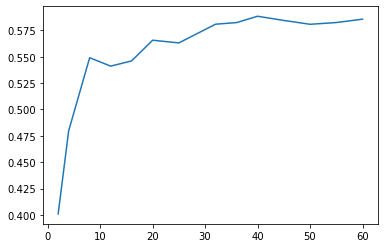

In [87]:
plt.plot(n_topics_ls, coherence_ls)

In [88]:
vis = pyLDAvis.gensim_models.prepare(models_ls[-1], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
11    -0.136821  0.013110       1        1  2.145223
32     0.123786 -0.144213       2        1  2.117832
23    -0.141097 -0.112082       3        1  1.990062
57    -0.190948 -0.132117       4        1  1.985552
56     0.195033 -0.157840       5        1  1.920322
10    -0.184879 -0.133013       6        1  1.911540
9      0.094909 -0.143580       7        1  1.890900
38     0.115644 -0.215671       8        1  1.890154
8      0.131947 -0.122919       9        1  1.867934
53    -0.029284 -0.180796      10        1  1.826956
54     0.004147 -0.221781      11        1  1.820127
21    -0.181950 -0.110920      12        1  1.817055
42    -0.053548  0.164478      13        1  1.805648
49    -0.142902 -0.129491      14        1  1.804562
31     0.015685  0.179851      15        1  1.800994
4      0.014752  0.041262      16        1  1.798791
24    -0.028302  0.047317      17        1  1.744830
5     -0.054161  0.008840      18        1  1.734732
33    -0.182977 -0.018422      19        1  1.715404
15    -0.164961 -0.003176      20        1  1.706879
7      0.169385 -0.026577      21        1  1.694551
18     0.087890 -0.092173      22        1  1.687480
58    -0.086764  0.081196      23        1  1.685286
52     0.084144  0.135435      24        1  1.679782
2     -0.165924  0.025798      25        1  1.676955
47     0.029357  0.161512      26        1  1.673274
48    -0.045666 -0.057064      27        1  1.673253
34    -0.130937  0.099897      28        1  1.669316
44     0.105484  0.106814      29        1  1.665082
16     0.013806  0.129054      30        1  1.654878
0      0.160850  0.039207      31        1  1.647657
39     0.199675 -0.059902      32        1  1.642199
43    -0.029030  0.129032      33        1  1.632123
22    -0.096345 -0.038948      34        1  1.620573
3      0.046969  0.030761      35        1  1.620346
25    -0.063639 -0.054048      36        1  1.612485
20     0.073478  0.091500      37        1  1.611696
14    -0.119717  0.040782      38        1  1.611631
26     0.090253 -0.115336      39        1  1.601795
35    -0.008230  0.156745      40        1  1.592226
1      0.059456  0.069931      41        1  1.587347
29    -0.013514  0.041498      42        1  1.581340
45     0.048239  0.066805      43        1  1.579404
12     0.118718  0.063178      44        1  1.576279
55     0.006787 -0.086088      45        1  1.571851
59     0.065679  0.105004      46        1  1.556044
19     0.159456 -0.071148      47        1  1.554597
13     0.000974  0.110825      48        1  1.543179
50    -0.047796 -0.054165      49        1  1.535059
6      0.074184  0.056051      50        1  1.534279
27    -0.054979 -0.008660      51        1  1.530651
37     0.147541  0.021889      52        1  1.523566
36    -0.037099  0.093235      53        1  1.517167
30    -0.156950  0.007259      54        1  1.512861
51     0.061141  0.099317      55        1  1.487215
40     0.041218 -0.045889      56        1  1.436883
41    -0.028364  0.116274      57        1  1.417813
46     0.014612  0.000087      58        1  1.277688
17    -0.003555  0.018324      59        1  1.238224
28     0.025139 -0.016249      60        1  1.190471, topic_info=          Term          Freq         Total Category  logprob  loglift
203      model  11282.000000  11282.000000  Default  30.0000  30.0000
113     system  12206.000000  12206.000000  Default  29.0000  29.0000
201     method  13596.000000  13596.000000  Default  28.0000  28.0000
43       group  10285.000000  10285.000000  Default  27.0000  27.0000
393       time  11135.000000  11135.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
353       data    321.513693  10628.770998  Topic60  -4.5892   0.9325
1713  abstract    180.288052   2890.620627  Topic60  -5.1677   1.6562
107   research    205.828859   6091.08563

In [89]:
vis = pyLDAvis.gensim_models.prepare(models_ls[0], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x    y  topics  cluster       Freq
topic                                           
1      0.276143  0.0       1        1  51.667874
0     -0.276143  0.0       2        1  48.332126, topic_info=             Term          Freq         Total Category  logprob  loglift
81          study  16345.000000  16345.000000  Default  30.0000  30.0000
1623      patient  15193.000000  15193.000000  Default  29.0000  29.0000
113        system  12620.000000  12620.000000  Default  28.0000  28.0000
203         model  11242.000000  11242.000000  Default  27.0000  27.0000
970          cell  11197.000000  11197.000000  Default  26.0000  26.0000
...           ...           ...           ...      ...      ...      ...
1349  information   3591.762981   4563.567246   Topic2  -5.8796   0.4876
908         state   3527.845270   5035.027233   Topic2  -5.8975   0.3713
1662     approach   3482.484314   4744.892426   Topic2  -5.9105   0.4178
172        effect   3656.711623  10857.229181   Topic2  -5.8617  -0.3612
534          rate   3521.659685   6653.723376   Topic2  -5.8993   0.0908

[165 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
795       1  0.999965    activity
2291      1  1.000047         age
152       1  1.000256         aim
1833      2  1.000154   algorithm
90        2  1.001037  allocation
...     ...       ...         ...
1614      2  0.999937       water
788       2  1.001287       wurde
920       1  0.999813        year
920       2  0.000153        year
793       2  1.001287         zum

[151 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 1])

In [90]:
vis = pyLDAvis.gensim_models.prepare(models_ls[4], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
1     -0.014787  0.273192       1        1  7.088965
2     -0.246441  0.126803       2        1  6.988485
9      0.117736  0.073619       3        1  6.852603
14    -0.274839  0.010444       4        1  6.529444
7      0.148197  0.163595       5        1  6.388602
5     -0.150917 -0.182771       6        1  6.319901
4      0.176400 -0.191972       7        1  6.257089
10    -0.237231 -0.000299       8        1  6.249078
13     0.097658 -0.211137       9        1  6.192409
11     0.070277  0.243293      10        1  6.163549
3     -0.084200 -0.195766      11        1  6.149081
6      0.018601 -0.032172      12        1  5.917758
8     -0.002043 -0.096188      13        1  5.915725
15     0.100226  0.058783      14        1  5.792655
12     0.074032 -0.008846      15        1  5.659803
0      0.207330 -0.030579      16        1  5.534855, topic_info=           Term          Freq         Total Category  logprob  loglift
1623    patient  14766.000000  14766.000000  Default  30.0000  30.0000
113      system  12133.000000  12133.000000  Default  29.0000  29.0000
970        cell  10911.000000  10911.000000  Default  28.0000  28.0000
201      method  13399.000000  13399.000000  Default  27.0000  27.0000
43        group  10507.000000  10507.000000  Default  26.0000  26.0000
...         ...           ...           ...      ...      ...      ...
160    chemical    677.663758   1503.871092  Topic16  -5.3803   2.0970
4          form    769.773395   2549.549467  Topic16  -5.2529   1.6965
2980       drug    640.381286   2326.918300  Topic16  -5.4369   1.6039
534        rate    642.574372   6718.211183  Topic16  -5.4335   0.5470
975   condition    583.361034   4967.042351  Topic16  -5.5302   0.7523

[1408 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
15        8  1.003018  abbreviation
1832     11  1.000150      accuracy
5023     16  1.000211       acetate
2039     16  0.999901          acid
229      14  0.905274         acoes
...     ...       ...           ...
5385      5  0.944852         yogic
5395      7  0.088283          zone
5395     12  0.912263          zone
792      13  0.931341           zte
1288      4  0.983094      zwischen

[2355 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 10, 15, 8, 6, 5, 11, 14, 12, 4, 7, 9, 16, 13, 1])

In [91]:
vis = pyLDAvis.gensim_models.prepare(models_ls[2], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.022239 -0.237988       1        1  14.318832
6      0.096548 -0.267541       2        1  13.005195
1     -0.278741 -0.007198       3        1  12.758673
2     -0.035513  0.233906       4        1  12.448952
0      0.058657 -0.096170       5        1  11.946428
5      0.182766  0.195973       6        1  11.938385
4      0.273537  0.083665       7        1  11.839649
7     -0.275014  0.095353       8        1  11.743886, topic_info=          Term          Freq         Total Category  logprob  loglift
1623   patient  14575.000000  14575.000000  Default  30.0000  30.0000
113     system  12340.000000  12340.000000  Default  29.0000  29.0000
970       cell  11191.000000  11191.000000  Default  28.0000  28.0000
43       group   9980.000000   9980.000000  Default  27.0000  27.0000
203      model  11043.000000  11043.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
1917    change   1528.566697   5234.871342   Topic8  -5.3191   0.9108
1821   article   1222.201517   2626.538637   Topic8  -5.5428   1.3768
107   research   1351.483278   6252.142725   Topic8  -5.4423   0.6101
193      level   1324.323244   8393.395902   Topic8  -5.4626   0.2953
2365      case   1281.953591   6816.330278   Topic8  -5.4951   0.4709

[694 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
118       1  1.000803  abnormality
2977      2  0.003838   absorption
2977      7  0.996614   absorption
656       3  0.999580     academic
1832      4  0.999715     accuracy
...     ...       ...          ...
920       1  0.575695         year
920       3  0.162336         year
920       5  0.164041         year
920       8  0.097991         year
599       2  0.960509   zasadniczy

[960 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 7, 2, 3, 1, 6, 5, 8])

In [92]:
n_topics_ls = list(range(7, 21))
models_ls = []
coherence_ls = []
for n in tqdm(n_topics_ls):
    ldamallet = gensim.models.wrappers.LdaMallet(mallet_path, corpus=corpus, num_topics=n, id2word=id2word, random_seed=42)
    coherence_model_ldamallet = CoherenceModel(model=ldamallet, texts=data_lemmatized, dictionary=id2word, coherence='c_v')
    coherence_ldamallet = coherence_model_ldamallet.get_coherence()
    
    model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(ldamallet)
    models_ls.append(model)
    coherence_ls.append(coherence_ldamallet)

2021-08-23 11:23:28,881 INFO: serializing temporary corpus to /tmp/15857e_corpus.txt
2021-08-23 11:23:30,321 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/15857e_corpus.txt --output /tmp/15857e_corpus.mallet
2021-08-23 11:23:32,599 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/15857e_corpus.mallet --num-topics 7  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/15857e_state.mallet.gz --output-doc-topics /tmp/15857e_doctopics.txt --output-topic-keys /tmp/15857e_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/15857e_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:25:09,102 INFO: loading assigned topics from /tmp/15857e_state.mallet.gz
2021-08-23 11:25:15,487 INFO: using ParallelWordOccurrenceAccumulator(processes=7, bat

2021-08-23 11:27:14,896 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/d889df_corpus.txt --output /tmp/d889df_corpus.mallet
2021-08-23 11:27:17,203 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/d889df_corpus.mallet --num-topics 9  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/d889df_state.mallet.gz --output-doc-topics /tmp/d889df_doctopics.txt --output-topic-keys /tmp/d889df_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/d889df_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:28:55,072 INFO: loading assigned topics from /tmp/d889df_state.mallet.gz
2021-08-23 11:29:01,340 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:29:03,841 IN

2021-08-23 11:31:03,045 INFO: serializing temporary corpus to /tmp/23a034_corpus.txt
2021-08-23 11:31:04,658 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/23a034_corpus.txt --output /tmp/23a034_corpus.mallet
2021-08-23 11:31:06,982 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/23a034_corpus.mallet --num-topics 11  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/23a034_state.mallet.gz --output-doc-topics /tmp/23a034_doctopics.txt --output-topic-keys /tmp/23a034_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/23a034_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:32:45,401 INFO: loading assigned topics from /tmp/23a034_state.mallet.gz
2021-08-23 11:32:51,334 INFO: using ParallelWordOccurrenceAccumulator(processes=7, ba

2021-08-23 11:34:56,998 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/2dc566_corpus.txt --output /tmp/2dc566_corpus.mallet
2021-08-23 11:34:59,282 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/2dc566_corpus.mallet --num-topics 13  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/2dc566_state.mallet.gz --output-doc-topics /tmp/2dc566_doctopics.txt --output-topic-keys /tmp/2dc566_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/2dc566_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:36:47,361 INFO: loading assigned topics from /tmp/2dc566_state.mallet.gz
2021-08-23 11:36:53,362 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:36:56,524 I

2021-08-23 11:39:10,855 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/1f9af8_corpus.mallet --num-topics 15  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/1f9af8_state.mallet.gz --output-doc-topics /tmp/1f9af8_doctopics.txt --output-topic-keys /tmp/1f9af8_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/1f9af8_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:41:00,210 INFO: loading assigned topics from /tmp/1f9af8_state.mallet.gz
2021-08-23 11:41:06,589 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:41:10,239 INFO: 225 batches submitted to accumulate stats from 14400 documents (-476762 virtual)
2021-08-23 11:41:10,530 INFO: 242 batches submitted to accumulate stats from 15488 documents (-499559 virtual)
2021-08-23 11:41:10,558 INFO: 243 batches submitted to accumulate stats from 1

2021-08-23 11:43:25,885 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/823cf6_corpus.mallet --num-topics 17  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/823cf6_state.mallet.gz --output-doc-topics /tmp/823cf6_doctopics.txt --output-topic-keys /tmp/823cf6_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/823cf6_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-23 11:45:15,832 INFO: loading assigned topics from /tmp/823cf6_state.mallet.gz
2021-08-23 11:45:21,795 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:45:25,786 INFO: 225 batches submitted to accumulate stats from 14400 documents (-477649 virtual)
2021-08-23 11:45:26,155 INFO: 242 batches submitted to accumulate stats from 15488 documents (-500561 virtual)
2021-08-23 11:45:26,161 INFO: 243 batches submitted to accumulate stats from 1

2021-08-23 11:49:31,565 INFO: loading assigned topics from /tmp/6fb0b2_state.mallet.gz
2021-08-23 11:49:37,584 INFO: using ParallelWordOccurrenceAccumulator(processes=7, batch_size=64) to estimate probabilities from sliding windows
2021-08-23 11:49:41,970 INFO: 225 batches submitted to accumulate stats from 14400 documents (-479302 virtual)
2021-08-23 11:49:42,327 INFO: 242 batches submitted to accumulate stats from 15488 documents (-502349 virtual)
2021-08-23 11:49:42,338 INFO: 244 batches submitted to accumulate stats from 15616 documents (-501872 virtual)
2021-08-23 11:49:42,529 INFO: 250 batches submitted to accumulate stats from 16000 documents (-504611 virtual)
2021-08-23 11:49:42,569 INFO: 251 batches submitted to accumulate stats from 16064 documents (-503693 virtual)
2021-08-23 11:49:42,574 INFO: 252 batches submitted to accumulate stats from 16128 documents (-503201 virtual)
2021-08-23 11:49:42,588 INFO: 253 batches submitted to accumulate stats from 16192 documents (-502979 

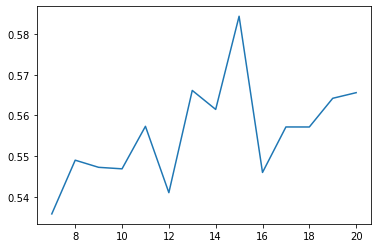

In [93]:
plt.plot(n_topics_ls, coherence_ls)

In [97]:
vis = pyLDAvis.gensim_models.prepare(models_ls[8], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
3     -0.091405  0.280492       1        1  7.637551
10    -0.138796  0.089000       2        1  7.334433
12     0.258220  0.130650       3        1  7.172234
13     0.252658  0.144171       4        1  7.121735
0     -0.148017  0.182380       5        1  6.932850
11    -0.241399  0.109517       6        1  6.830505
1     -0.035831 -0.000122       7        1  6.743268
8     -0.033718  0.057698       8        1  6.593685
9      0.271643  0.000892       9        1  6.539158
14     0.112740 -0.124830      10        1  6.399292
6      0.032063 -0.206891      11        1  6.295532
7     -0.112540 -0.220009      12        1  6.278065
4      0.008824 -0.106968      13        1  6.150346
2     -0.001974 -0.188941      14        1  6.075257
5     -0.132470 -0.147041      15        1  5.896090, topic_info=          Term          Freq         Total Category  logprob  loglift
81       study  16588.000000  16588.000000  Default  30.0000  30.0000
1623   patient  14853.000000  14853.000000  Default  29.0000  29.0000
970       cell  10930.000000  10930.000000  Default  28.0000  28.0000
201     method  13091.000000  13091.000000  Default  27.0000  27.0000
113     system  12614.000000  12614.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
4         form    853.606905   2506.461980  Topic15  -5.2127   1.7537
1435    medium    681.349470   1886.685712  Topic15  -5.4381   1.8124
795   activity    826.177377   5039.396765  Topic15  -5.2454   1.0226
848   addition    698.904368   2721.036975  Topic15  -5.4127   1.4716
1796   protein    623.198871   4233.329083  Topic15  -5.5273   0.9150

[1320 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
3040      5  0.999430   abdominal
605      14  0.936982     abfolge
2766      5  0.999550    abnormal
922       8  0.934602   absterben
656       4  0.999309    academic
...     ...       ...         ...
599       6  0.953914  zasadniczy
1279      1  0.993198      ziehen
602      13  0.923347    zjawisko
5395      7  0.757302        zone
5395     12  0.243316        zone

[2084 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 11, 13, 14, 1, 12, 2, 9, 10, 15, 7, 8, 5, 3, 6])

In [96]:
vis = pyLDAvis.gensim_models.prepare(models_ls[3], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
8      0.287878  0.035066       1        1  11.427943
3      0.043571  0.250956       2        1  11.422949
5     -0.098058  0.176575       3        1  10.326652
4     -0.137785  0.221307       4        1   9.932653
1      0.107302 -0.224533       5        1   9.713042
9      0.024582 -0.173891       6        1   9.677777
6     -0.039462  0.050479       7        1   9.603249
0     -0.194008 -0.197086       8        1   9.547600
7     -0.249476 -0.107692       9        1   9.512185
2      0.255455 -0.031181      10        1   8.835949, topic_info=          Term          Freq         Total Category  logprob  loglift
1623   patient  14573.000000  14573.000000  Default  30.0000  30.0000
113     system  12478.000000  12478.000000  Default  29.0000  29.0000
203      model  11149.000000  11149.000000  Default  28.0000  28.0000
970       cell  11228.000000  11228.000000  Default  27.0000  27.0000
43       group  10542.000000  10542.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
2001    common    871.711928   2286.653535  Topic10  -5.5963   1.4620
1940     human    910.760947   4030.450920  Topic10  -5.5524   0.9390
223       term    790.168388   3636.202037  Topic10  -5.6945   0.8999
377   relation    753.416370   1472.927524  Topic10  -5.7421   1.7560
393       time    761.455874  10265.147430  Topic10  -5.7315  -0.1749

[851 rows x 6 columns], token_table=      Topic      Freq            Term
term                                 
15       10  0.991631    abbreviation
922       4  0.935549       absterben
1832      6  1.000254        accuracy
1911      6  0.996327        accurate
1911      8  0.004204        accurate
...     ...       ...             ...
920       6  0.000158            year
920       7  0.176524            year
598       4  0.935549           zanim
599       9  0.978133      zasadniczy
1286      9  0.978133  zuruckzufuhren

[1301 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[9, 4, 6, 5, 2, 10, 7, 1, 8, 3])

In [98]:
vis = pyLDAvis.gensim_models.prepare(models_ls[1], corpus, id2word)
vis

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.022239 -0.237988       1        1  14.318834
6      0.096548 -0.267541       2        1  13.005195
1     -0.278741 -0.007198       3        1  12.758668
2     -0.035513  0.233906       4        1  12.448951
0      0.058657 -0.096170       5        1  11.946429
5      0.182766  0.195973       6        1  11.938385
4      0.273537  0.083665       7        1  11.839648
7     -0.275014  0.095353       8        1  11.743890, topic_info=          Term          Freq         Total Category  logprob  loglift
1623   patient  14575.000000  14575.000000  Default  30.0000  30.0000
113     system  12340.000000  12340.000000  Default  29.0000  29.0000
970       cell  11191.000000  11191.000000  Default  28.0000  28.0000
43       group   9980.000000   9980.000000  Default  27.0000  27.0000
203      model  11043.000000  11043.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
1917    change   1528.567152   5234.872013   Topic8  -5.3191   0.9108
1821   article   1222.201881   2626.538542   Topic8  -5.5428   1.3768
107   research   1351.483680   6252.141528   Topic8  -5.4423   0.6101
193      level   1324.323638   8393.396316   Topic8  -5.4626   0.2953
2365      case   1281.953973   6816.331169   Topic8  -5.4951   0.4709

[693 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
1711      1  1.000803        abcam
118       1  1.000803  abnormality
2977      2  0.003838   absorption
2977      7  0.996614   absorption
656       3  0.999581     academic
...     ...       ...          ...
920       3  0.162336         year
920       5  0.164041         year
920       8  0.097991         year
599       2  0.960509   zasadniczy
792       7  0.977492          zte

[959 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 7, 2, 3, 1, 6, 5, 8])

In [35]:
from concurrent.futures import ProcessPoolExecutor


def process_abstracts(abs_data, num_workers=4):

    with ProcessPoolExecutor(max_workers=num_workers) as pool:
        with tqdm(total=len(abs_data)) as progress:
            futures = []

            for item in abs_data:
                future = pool.submit(tokenize, item)
                future.add_done_callback(lambda p: progress.update())
                futures.append(future)

            results = []
            for future in futures:
                result = future.result()
                results.append(result)
    return results

In [36]:
corpus_abs_full = [f'{item}' for ssid, item in abstracts]
full_abs_lemm = process_abstracts(corpus_abs_full)
# full_abs_lemm = [tokenize(item) for item in tqdm(corpus_abs_full)]
result_full_vectors = {}

In [37]:
id2word_full = corpora.Dictionary(full_abs_lemm)
texts_full = full_abs_lemm

# Term Document Frequency
corpus_full = [id2word_full.doc2bow(text) for text in texts_full]

# View
print(corpus_full[:1])

2021-08-24 19:20:11,140 INFO: adding document #0 to Dictionary(0 unique tokens: [])
2021-08-24 19:20:11,782 INFO: adding document #10000 to Dictionary(60242 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:12,451 INFO: adding document #20000 to Dictionary(95423 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:13,953 INFO: adding document #30000 to Dictionary(123596 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:14,619 INFO: adding document #40000 to Dictionary(148631 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:15,297 INFO: adding document #50000 to Dictionary(171393 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:15,979 INFO: adding document #60000 to Dictionary(194140 unique tokens: ['acute', 'aetiology', 'agent

2021-08-24 19:20:48,944 INFO: adding document #520000 to Dictionary(747669 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:49,608 INFO: adding document #530000 to Dictionary(753777 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:50,278 INFO: adding document #540000 to Dictionary(760056 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:50,950 INFO: adding document #550000 to Dictionary(766160 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:51,625 INFO: adding document #560000 to Dictionary(772067 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:52,302 INFO: adding document #570000 to Dictionary(777984 unique tokens: ['acute', 'aetiology', 'agent', 'anticoagulant', 'antithrombotic']...)
2021-08-24 19:20:52,975 INFO: addi

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 2), (17, 1), (18, 1), (19, 1), (20, 3), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 2), (31, 2), (32, 1), (33, 2), (34, 1), (35, 2), (36, 1), (37, 1), (38, 1), (39, 1), (40, 3), (41, 2), (42, 1), (43, 6), (44, 1), (45, 2), (46, 1), (47, 1), (48, 2), (49, 1), (50, 1), (51, 1), (52, 1), (53, 2), (54, 1)]]


In [38]:
ldamallet = gensim.models.wrappers.LdaMallet(mallet_path, corpus=corpus_full, num_topics=8, id2word=id2word_full, random_seed=42)
coherence_model_ldamallet = CoherenceModel(model=ldamallet, texts=full_abs_lemm, dictionary=id2word_full, coherence='c_v')
coherence_ldamallet = coherence_model_ldamallet.get_coherence()

2021-08-24 19:21:28,568 INFO: serializing temporary corpus to /tmp/206204_corpus.txt
2021-08-24 19:21:58,172 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/206204_corpus.txt --output /tmp/206204_corpus.mallet
2021-08-24 19:22:35,075 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/206204_corpus.mallet --num-topics 8  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/206204_state.mallet.gz --output-doc-topics /tmp/206204_doctopics.txt --output-topic-keys /tmp/206204_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/206204_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-24 19:56:30,080 INFO: loading assigned topics from /tmp/206204_state.mallet.gz
2021-08-24 19:58:33,790 INFO: using ParallelWordOccurrenceAccumulator(processes=7, bat

2021-08-24 19:59:21,833 INFO: 4853 batches submitted to accumulate stats from 310592 documents (-9871670 virtual)
2021-08-24 19:59:21,838 INFO: 4854 batches submitted to accumulate stats from 310656 documents (-9871608 virtual)
2021-08-24 19:59:21,872 INFO: 4855 batches submitted to accumulate stats from 310720 documents (-9871274 virtual)
2021-08-24 19:59:21,886 INFO: 4857 batches submitted to accumulate stats from 310848 documents (-9871755 virtual)
2021-08-24 19:59:21,947 INFO: 4861 batches submitted to accumulate stats from 311104 documents (-9872078 virtual)
2021-08-24 19:59:22,031 INFO: 4866 batches submitted to accumulate stats from 311424 documents (-9873912 virtual)
2021-08-24 19:59:22,050 INFO: 4867 batches submitted to accumulate stats from 311488 documents (-9873560 virtual)
2021-08-24 19:59:22,071 INFO: 4868 batches submitted to accumulate stats from 311552 documents (-9872541 virtual)
2021-08-24 19:59:22,737 INFO: 4925 batches submitted to accumulate stats from 315200 doc

2021-08-24 19:59:24,342 INFO: 5018 batches submitted to accumulate stats from 321152 documents (-9904136 virtual)
2021-08-24 19:59:24,365 INFO: 5019 batches submitted to accumulate stats from 321216 documents (-9903683 virtual)
2021-08-24 19:59:24,382 INFO: 5020 batches submitted to accumulate stats from 321280 documents (-9903023 virtual)
2021-08-24 19:59:24,398 INFO: 5021 batches submitted to accumulate stats from 321344 documents (-9901608 virtual)
2021-08-24 19:59:24,403 INFO: 5022 batches submitted to accumulate stats from 321408 documents (-9901286 virtual)
2021-08-24 19:59:24,436 INFO: 5023 batches submitted to accumulate stats from 321472 documents (-9900732 virtual)
2021-08-24 19:59:24,441 INFO: 5024 batches submitted to accumulate stats from 321536 documents (-9900469 virtual)
2021-08-24 19:59:24,463 INFO: 5025 batches submitted to accumulate stats from 321600 documents (-9899605 virtual)
2021-08-24 19:59:24,484 INFO: 5026 batches submitted to accumulate stats from 321664 doc

2021-08-24 19:59:25,785 INFO: 5114 batches submitted to accumulate stats from 327296 documents (-9876566 virtual)
2021-08-24 19:59:25,794 INFO: 5115 batches submitted to accumulate stats from 327360 documents (-9876549 virtual)
2021-08-24 19:59:25,843 INFO: 5117 batches submitted to accumulate stats from 327488 documents (-9876362 virtual)
2021-08-24 19:59:25,874 INFO: 5119 batches submitted to accumulate stats from 327616 documents (-9876497 virtual)
2021-08-24 19:59:25,905 INFO: 5121 batches submitted to accumulate stats from 327744 documents (-9876684 virtual)
2021-08-24 19:59:25,910 INFO: 5122 batches submitted to accumulate stats from 327808 documents (-9875966 virtual)
2021-08-24 19:59:25,915 INFO: 5123 batches submitted to accumulate stats from 327872 documents (-9875762 virtual)
2021-08-24 19:59:25,938 INFO: 5124 batches submitted to accumulate stats from 327936 documents (-9875631 virtual)
2021-08-24 19:59:25,987 INFO: 5126 batches submitted to accumulate stats from 328064 doc

2021-08-24 19:59:27,292 INFO: 5220 batches submitted to accumulate stats from 334080 documents (-9858378 virtual)
2021-08-24 19:59:27,305 INFO: 5221 batches submitted to accumulate stats from 334144 documents (-9857948 virtual)
2021-08-24 19:59:27,313 INFO: 5222 batches submitted to accumulate stats from 334208 documents (-9857144 virtual)
2021-08-24 19:59:27,345 INFO: 5223 batches submitted to accumulate stats from 334272 documents (-9856770 virtual)
2021-08-24 19:59:27,350 INFO: 5224 batches submitted to accumulate stats from 334336 documents (-9856707 virtual)
2021-08-24 19:59:27,361 INFO: 5225 batches submitted to accumulate stats from 334400 documents (-9855930 virtual)
2021-08-24 19:59:27,367 INFO: 5226 batches submitted to accumulate stats from 334464 documents (-9855722 virtual)
2021-08-24 19:59:27,389 INFO: 5227 batches submitted to accumulate stats from 334528 documents (-9854915 virtual)
2021-08-24 19:59:27,419 INFO: 5229 batches submitted to accumulate stats from 334656 doc

2021-08-24 20:00:12,411 INFO: 7 accumulators retrieved from output queue
2021-08-24 20:00:12,428 INFO: accumulated word occurrence stats for 5889874 virtual documents


In [39]:
target_model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(ldamallet)
vis = pyLDAvis.gensim_models.prepare(target_model, corpus_full, id2word_full, sort_topics=False)
vis

2021-08-24 20:00:13,045 INFO: using serial LDA version on this node
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/pyLDAvis/_prepare.py:247: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  by='saliency', ascending=False).head(R).drop('saliency', 1)


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.048613  0.055548       1        1  11.845724
1     -0.130708 -0.197083       2        1  12.221673
2     -0.220425  0.124324       3        1  13.017723
3     -0.252084 -0.114394       4        1  13.141797
4      0.035548  0.315896       5        1  12.546641
5      0.190920 -0.241113       6        1  13.629255
6      0.229601 -0.023998       7        1  11.944582
7      0.195760  0.080820       8        1  11.652606, topic_info=          Term           Freq          Total Category  logprob  loglift
30     patient  302098.000000  302098.000000  Default  30.0000  30.0000
648     system  257985.000000  257985.000000  Default  29.0000  29.0000
193      model  228964.000000  228964.000000  Default  28.0000  28.0000
411       cell  223761.000000  223761.000000  Default  27.0000  27.0000
155      study  347747.000000  347747.000000  Default  26.0000  26.0000
..         ...            ...            ...      ...      ...      ...
709      class   22812.673149   32656.897008   Topic8  -5.6118   1.7909
196      paper   38897.320192  150716.454205   Topic8  -5.0782   0.7952
702  structure   34710.689332  109076.823918   Topic8  -5.1920   1.0046
87   condition   31588.313694  100053.223127   Topic8  -5.2863   0.9967
383      state   28915.593768   97055.203373   Topic8  -5.3747   0.9387

[681 rows x 6 columns], token_table=       Topic      Freq        Term
term                              
501        8  0.998145        aber
2880       5  1.000021  absorption
502        8  0.951839   abstanden
43739      6  0.995128       accra
940        8  1.000009    accuracy
...      ...       ...         ...
999        1  0.857637       yield
999        2  0.000039       yield
999        5  0.142329       yield
215        1  0.924553        zone
215        5  0.075475        zone

[977 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8])

In [40]:
coherence_ldamallet

0.5573434977548892

In [120]:
len(texts_full), len(abstracts)

(727314, 727314)

In [124]:
results_lda = {}
for (ssid, _), txt in tqdm(zip(abstracts, corpus_full)):
    vect = target_model[txt]
    results_lda[ssid] = vect

In [75]:
def diversity(ls, eps=1e-8):
    ans = 0
    for _, p in ls:
        ans += -p * np.log(p + eps)
    return ans / len(ls)


def get_dom_topic(ls):
    return np.argmax(ls, axis=0)[1] + 1


def calc_lda_features(data):
    result_features = {}
    for key, vect in tqdm(data.items()):
        tmp = [0] * len(vect)
        for x, y in vect:
            tmp[x] = y
        result_features[key] = (diversity(vect), get_dom_topic(vect), tmp)
    return result_features

In [76]:
lda_features = calc_lda_features(results_lda)

NameError: name 'results_lda' is not defined

In [ ]:
df = pd.read_csv('tmp_data/total_dfv2.csv')
df = df.set_index('idx')
eng_df = df.loc[results_lda.keys()]
feature_columns = ['diversity', 'dominant_topic'] + [f'topic_{i + 1}' for i in range(15)]
for name in feature_columns:
    eng_df[name] = [0 for _ in range(len(eng_df))]
    
diversities_ls = [lda_features[key][0] for key in eng_df.index]
dom_ls = [lda_features[key][1] for key in eng_df.index]
topics_dict = {f'topic_{i + 1}': [] for i in range(15)}
for key in eng_df.index:
    for i, el in enumerate(lda_features[key][-1]):
        topics_dict[f'topic_{i + 1}'].append(el)
        
    

In [203]:
eng_df['diversity'] = diversities_ls
eng_df['dominant_topic'] = dom_ls
for key in topics_dict:
    eng_df[key] = topics_dict[key]

In [205]:
eng_df.to_csv('tmp_data/total_df_eng_lda.csv')

In [54]:
from collections import Counter



def get_journals_info(model, n_topics, n_tops=10):
    results_lda = {}
    for (ssid, _), txt in tqdm(zip(abstracts, corpus_full)):
        vect = model[txt]
        results_lda[ssid] = get_dom_topic(vect)
    df = pd.DataFrame(results_lda.items(), columns=['idx', 'dom'])
    df = df.set_index('idx')
    ans = {}
    for i in tqdm(range(n_topics)):
        ls = list(df[df.dom == i + 1].index)
        q = f'''select distinct ssid, venue_id from venues_papers_authors where ssid in ({", ".join(map(lambda x: f"'{x}'", ls))})'''
        res = loader.custom_query(q)
        vens = [y for x, y in res]
        d = Counter(vens).most_common(n_tops)
        ls = [x for x, y in d]
        q = f'''select venue_name, total_citations, total_papers from venues where venue_id in ({', '.join(map(str, ls))}) order by total_citations desc;'''
        ans[i + 1] = loader.custom_query(q)
    return ans

In [55]:
n_topics_ls = [8, 12, 20, 30]
models_ls = []
coherence_ls = []
for n in tqdm(n_topics_ls):
    ldamallet = gensim.models.wrappers.LdaMallet(mallet_path, corpus=corpus_full, num_topics=n, id2word=id2word_full, random_seed=42)
    coherence_model_ldamallet = CoherenceModel(model=ldamallet, texts=full_abs_lemm, dictionary=id2word_full, coherence='c_v')
    coherence_ldamallet = coherence_model_ldamallet.get_coherence()
    
    model = gensim.models.wrappers.ldamallet.malletmodel2ldamodel(ldamallet)
    models_ls.append(model)
    coherence_ls.append(coherence_ldamallet)

journals_d = {}
for model, n in zip(models_ls, n_topics_ls):
    journals_d[n] = get_journals_info(model, n)
    

2021-08-25 00:40:48,995 INFO: serializing temporary corpus to /tmp/231d29_corpus.txt
2021-08-25 00:41:18,698 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/231d29_corpus.txt --output /tmp/231d29_corpus.mallet
2021-08-25 00:41:55,050 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/231d29_corpus.mallet --num-topics 8  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/231d29_state.mallet.gz --output-doc-topics /tmp/231d29_doctopics.txt --output-topic-keys /tmp/231d29_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/231d29_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-25 01:16:09,353 INFO: loading assigned topics from /tmp/231d29_state.mallet.gz
2021-08-25 01:18:11,891 INFO: using ParallelWordOccurrenceAccumulator(processes=7, bat

2021-08-25 01:19:00,197 INFO: 4853 batches submitted to accumulate stats from 310592 documents (-9871670 virtual)
2021-08-25 01:19:00,206 INFO: 4854 batches submitted to accumulate stats from 310656 documents (-9871608 virtual)
2021-08-25 01:19:00,215 INFO: 4855 batches submitted to accumulate stats from 310720 documents (-9871274 virtual)
2021-08-25 01:19:00,223 INFO: 4857 batches submitted to accumulate stats from 310848 documents (-9871755 virtual)
2021-08-25 01:19:00,307 INFO: 4861 batches submitted to accumulate stats from 311104 documents (-9872078 virtual)
2021-08-25 01:19:00,373 INFO: 4866 batches submitted to accumulate stats from 311424 documents (-9873912 virtual)
2021-08-25 01:19:00,379 INFO: 4867 batches submitted to accumulate stats from 311488 documents (-9873560 virtual)
2021-08-25 01:19:00,432 INFO: 4868 batches submitted to accumulate stats from 311552 documents (-9872541 virtual)
2021-08-25 01:19:01,097 INFO: 4925 batches submitted to accumulate stats from 315200 doc

2021-08-25 01:19:02,706 INFO: 5018 batches submitted to accumulate stats from 321152 documents (-9904136 virtual)
2021-08-25 01:19:02,718 INFO: 5019 batches submitted to accumulate stats from 321216 documents (-9903683 virtual)
2021-08-25 01:19:02,729 INFO: 5020 batches submitted to accumulate stats from 321280 documents (-9903023 virtual)
2021-08-25 01:19:02,746 INFO: 5021 batches submitted to accumulate stats from 321344 documents (-9901608 virtual)
2021-08-25 01:19:02,751 INFO: 5022 batches submitted to accumulate stats from 321408 documents (-9901286 virtual)
2021-08-25 01:19:02,789 INFO: 5023 batches submitted to accumulate stats from 321472 documents (-9900732 virtual)
2021-08-25 01:19:02,800 INFO: 5024 batches submitted to accumulate stats from 321536 documents (-9900469 virtual)
2021-08-25 01:19:02,824 INFO: 5025 batches submitted to accumulate stats from 321600 documents (-9899605 virtual)
2021-08-25 01:19:02,829 INFO: 5026 batches submitted to accumulate stats from 321664 doc

2021-08-25 01:19:04,141 INFO: 5114 batches submitted to accumulate stats from 327296 documents (-9876566 virtual)
2021-08-25 01:19:04,146 INFO: 5115 batches submitted to accumulate stats from 327360 documents (-9876549 virtual)
2021-08-25 01:19:04,208 INFO: 5117 batches submitted to accumulate stats from 327488 documents (-9876362 virtual)
2021-08-25 01:19:04,237 INFO: 5119 batches submitted to accumulate stats from 327616 documents (-9876497 virtual)
2021-08-25 01:19:04,247 INFO: 5121 batches submitted to accumulate stats from 327744 documents (-9876684 virtual)
2021-08-25 01:19:04,263 INFO: 5122 batches submitted to accumulate stats from 327808 documents (-9875966 virtual)
2021-08-25 01:19:04,269 INFO: 5123 batches submitted to accumulate stats from 327872 documents (-9875762 virtual)
2021-08-25 01:19:04,313 INFO: 5124 batches submitted to accumulate stats from 327936 documents (-9875631 virtual)
2021-08-25 01:19:04,352 INFO: 5126 batches submitted to accumulate stats from 328064 doc

2021-08-25 01:19:05,670 INFO: 5220 batches submitted to accumulate stats from 334080 documents (-9858378 virtual)
2021-08-25 01:19:05,675 INFO: 5221 batches submitted to accumulate stats from 334144 documents (-9857948 virtual)
2021-08-25 01:19:05,683 INFO: 5222 batches submitted to accumulate stats from 334208 documents (-9857144 virtual)
2021-08-25 01:19:05,696 INFO: 5223 batches submitted to accumulate stats from 334272 documents (-9856770 virtual)
2021-08-25 01:19:05,706 INFO: 5224 batches submitted to accumulate stats from 334336 documents (-9856707 virtual)
2021-08-25 01:19:05,715 INFO: 5225 batches submitted to accumulate stats from 334400 documents (-9855930 virtual)
2021-08-25 01:19:05,735 INFO: 5226 batches submitted to accumulate stats from 334464 documents (-9855722 virtual)
2021-08-25 01:19:05,748 INFO: 5227 batches submitted to accumulate stats from 334528 documents (-9854915 virtual)
2021-08-25 01:19:05,790 INFO: 5229 batches submitted to accumulate stats from 334656 doc

...

2021-08-25 02:02:31,950 INFO: using serial LDA version on this node
2021-08-25 02:02:33,116 INFO: serializing temporary corpus to /tmp/a37922_corpus.txt
2021-08-25 02:03:03,350 INFO: converting temporary corpus to MALLET format with tmp_data/mallet_model/mallet-2.0.8/bin/mallet import-file --preserve-case --keep-sequence --remove-stopwords --token-regex "\S+" --input /tmp/a37922_corpus.txt --output /tmp/a37922_corpus.mallet
2021-08-25 02:03:40,137 INFO: training MALLET LDA with tmp_data/mallet_model/mallet-2.0.8/bin/mallet train-topics --input /tmp/a37922_corpus.mallet --num-topics 20  --alpha 50 --optimize-interval 0 --num-threads 4 --output-state /tmp/a37922_state.mallet.gz --output-doc-topics /tmp/a37922_doctopics.txt --output-topic-keys /tmp/a37922_topickeys.txt --num-iterations 1000 --inferencer-filename /tmp/a37922_inferencer.mallet --doc-topics-threshold 0.0  --random-seed 42
2021-08-25 02:47:32,001 INFO: loading assigned topics from /tmp/a37922_state.mallet.gz
2021-08-25 02:49:

2021-08-25 02:51:13,045 INFO: 4921 batches submitted to accumulate stats from 314944 documents (-10232691 virtual)
2021-08-25 02:51:13,070 INFO: 4922 batches submitted to accumulate stats from 315008 documents (-10232467 virtual)
2021-08-25 02:51:13,185 INFO: 4926 batches submitted to accumulate stats from 315264 documents (-10233819 virtual)
2021-08-25 02:51:13,191 INFO: 4927 batches submitted to accumulate stats from 315328 documents (-10232972 virtual)
2021-08-25 02:51:13,359 INFO: 4932 batches submitted to accumulate stats from 315648 documents (-10234384 virtual)
2021-08-25 02:51:13,404 INFO: 4934 batches submitted to accumulate stats from 315776 documents (-10234198 virtual)
2021-08-25 02:51:13,592 INFO: 4940 batches submitted to accumulate stats from 316160 documents (-10235486 virtual)
2021-08-25 02:51:13,644 INFO: 4941 batches submitted to accumulate stats from 316224 documents (-10235168 virtual)
2021-08-25 02:51:14,369 INFO: 4968 batches submitted to accumulate stats from 31

2021-08-25 02:51:18,459 INFO: 5096 batches submitted to accumulate stats from 326144 documents (-10268807 virtual)
2021-08-25 02:51:18,464 INFO: 5097 batches submitted to accumulate stats from 326208 documents (-10268202 virtual)
2021-08-25 02:51:18,470 INFO: 5098 batches submitted to accumulate stats from 326272 documents (-10268016 virtual)
2021-08-25 02:51:18,550 INFO: 5099 batches submitted to accumulate stats from 326336 documents (-10267005 virtual)
2021-08-25 02:51:18,612 INFO: 5100 batches submitted to accumulate stats from 326400 documents (-10266793 virtual)
2021-08-25 02:51:18,617 INFO: 5101 batches submitted to accumulate stats from 326464 documents (-10265877 virtual)
2021-08-25 02:51:18,650 INFO: 5102 batches submitted to accumulate stats from 326528 documents (-10264972 virtual)
2021-08-25 02:51:18,723 INFO: 5103 batches submitted to accumulate stats from 326592 documents (-10264967 virtual)
2021-08-25 02:51:18,791 INFO: 5104 batches submitted to accumulate stats from 32

2021-08-25 02:51:21,779 INFO: 5201 batches submitted to accumulate stats from 332864 documents (-10245151 virtual)
2021-08-25 02:51:21,784 INFO: 5202 batches submitted to accumulate stats from 332928 documents (-10244744 virtual)
2021-08-25 02:51:21,790 INFO: 5203 batches submitted to accumulate stats from 332992 documents (-10243956 virtual)
2021-08-25 02:51:21,833 INFO: 5204 batches submitted to accumulate stats from 333056 documents (-10242947 virtual)
2021-08-25 02:51:21,848 INFO: 5205 batches submitted to accumulate stats from 333120 documents (-10242577 virtual)
2021-08-25 02:51:21,910 INFO: 5207 batches submitted to accumulate stats from 333248 documents (-10242494 virtual)
2021-08-25 02:51:21,982 INFO: 5208 batches submitted to accumulate stats from 333312 documents (-10242262 virtual)
2021-08-25 02:51:22,000 INFO: 5210 batches submitted to accumulate stats from 333440 documents (-10242531 virtual)
2021-08-25 02:51:22,069 INFO: 5212 batches submitted to accumulate stats from 33

2021-08-25 02:51:24,856 INFO: 5305 batches submitted to accumulate stats from 339520 documents (-10225658 virtual)
2021-08-25 02:51:24,878 INFO: 5306 batches submitted to accumulate stats from 339584 documents (-10225496 virtual)
2021-08-25 02:51:24,884 INFO: 5307 batches submitted to accumulate stats from 339648 documents (-10225001 virtual)
2021-08-25 02:51:25,013 INFO: 5310 batches submitted to accumulate stats from 339840 documents (-10225849 virtual)
2021-08-25 02:51:25,085 INFO: 5312 batches submitted to accumulate stats from 339968 documents (-10225571 virtual)
2021-08-25 02:51:25,094 INFO: 5313 batches submitted to accumulate stats from 340032 documents (-10225323 virtual)
2021-08-25 02:51:25,118 INFO: 5314 batches submitted to accumulate stats from 340096 documents (-10225170 virtual)
2021-08-25 02:51:25,148 INFO: 5315 batches submitted to accumulate stats from 340160 documents (-10225136 virtual)
2021-08-25 02:51:25,153 INFO: 5316 batches submitted to accumulate stats from 34

In [90]:
for model, n in zip(models_ls, n_topics_ls):
    journals_d[n] = get_journals_info(model, n, 20)

IndexError: invalid index to scalar variable.

In [86]:
def insert_features(model):
    results_lda = {}
    for (ssid, _), txt in tqdm(zip(abstracts, corpus_full)):
        vect = model[txt]
        results_lda[ssid] = vect
        
    lda_features = calc_lda_features(results_lda, model.num_topics)
    
    df = pd.read_csv('tmp_data/total_dfv2.csv')
    df = df.set_index('idx')
    eng_df = df.loc[results_lda.keys()]
    feature_columns = ['diversity', 'dominant_topic'] + [f'topic_{i + 1}' for i in range(model.num_topics)]
    for name in feature_columns:
        eng_df[name] = [0 for _ in range(len(eng_df))]

    diversities_ls = [lda_features[key][0] for key in eng_df.index]
    dom_ls = [lda_features[key][1] for key in eng_df.index]
    topics_dict = {f'topic_{i + 1}': [] for i in range(model.num_topics)}
    for key in eng_df.index:
        for i, el in enumerate(lda_features[key][-1]):
            topics_dict[f'topic_{i + 1}'].append(el)
            
    eng_df['diversity'] = diversities_ls
    eng_df['dominant_topic'] = dom_ls
    for key in topics_dict:
        eng_df[key] = topics_dict[key]
    eng_df.to_csv(f'tmp_data/total_df_eng_lda_{model.num_topics}.csv')

In [87]:
for model in tqdm(models_ls):
    insert_features(model)